# ROI Lens: Advanced Marketing Attribution & Budget Optimization Strategy

### Objective
To identify attribution blind spots in legacy last-click attribution and build a multi-touch marketing attribution framework for better ROI-driven budget allocation.

# 1. Business Problem Statement

The company currently relies on a legacy last-click attribution model, which assigns 100% conversion credit to the final marketing touchpoint. This ignores the contribution of upper-funnel channels such as influencer marketing, YouTube, and Instagram.

The objective of ROI Lens is to identify true channel contribution using customer journey analysis and a multi-touch attribution framework.

In [1]:
import pandas as pd
import numpy as np

# 2. Data Loading

In [3]:
touchpoints = pd.read_csv("C:/Users/91992/Desktop/ROI Lens Project/data/touchpoints.csv")

user_profiles = pd.read_csv("C:/Users/91992/Desktop/ROI Lens Project/data/user_profiles.csv")

campaign_spend = pd.read_csv("C:/Users/91992/Desktop/ROI Lens Project/data/campaign_spend.csv")

In [4]:
touchpoints.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type
0,U_B01_00000,01-01-2026 19:27,CMP_B01_INF_899,Influencer Blog,Impression
1,U_B01_00001,01-01-2026 20:37,CMP_B01_GOO_434,Google Search,Impression
2,U_B01_00001,01-01-2026 20:38,CMP_B01_GOO_434,Google Search,Click
3,U_B01_00001,01-04-2026 15:37,CMP_B01_MAR_127,Marketplace,Impression
4,U_B01_00001,01-06-2026 08:37,CMP_B01_INS_285,Instagram,Impression


In [5]:
user_profiles.head()

,User_ID,Segment,Trend_Affinity,Geography
0,U_B01_00000,Fitness Enthusiast,Sustainable Packaging,Tier 1
1,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1
2,U_B01_00002,Gen-Z Trendseeker,Sustainable Packaging,Tier 1
3,U_B01_00003,Premium Gourmet,Value-Pack,Tier 3
4,U_B01_00004,Gen-Z Trendseeker,Value-Pack,Tier 2


In [6]:
campaign_spend.head()

,Campaign_ID,Brand_ID,Channel,Pricing_Model,Cost_Rate_INR,Total_Budget_Allocated
0,CMP_B01_INS_285,B01,Instagram,CPM,391.98,613144.27
1,CMP_B01_GOO_434,B01,Google Search,CPC,23.41,27896859.25
2,CMP_B01_INF_899,B01,Influencer Blog,CPM,329.34,14499430.43
3,CMP_B01_YOU_211,B01,YouTube,CPM,180.36,19807806.26
4,CMP_B01_MAR_127,B01,Marketplace,CPC,37.54,37182759.79


In [7]:
print("Touchpoints Shape:", touchpoints.shape)

print("User Profiles Shape:", user_profiles.shape)

print("Campaign Spend Shape:", campaign_spend.shape)

Touchpoints Shape: (566510, 5)
User Profiles Shape: (100000, 4)
Campaign Spend Shape: (50, 6)


In [8]:
print("Touchpoints Columns:")
print(touchpoints.columns)

print("\nUser Profile Columns:")
print(user_profiles.columns)

print("\nCampaign Spend Columns:")
print(campaign_spend.columns)

Touchpoints Columns:
Index(['User_ID', 'Timestamp', 'Campaign_ID', 'Channel', 'Event_Type'], dtype='object')

User Profile Columns:
Index(['User_ID', 'Segment', 'Trend_Affinity', 'Geography'], dtype='object')

Campaign Spend Columns:
Index(['Campaign_ID', 'Brand_ID', 'Channel', 'Pricing_Model', 'Cost_Rate_INR',
       'Total_Budget_Allocated'],
      dtype='object')


# 3. Data Cleaning & Preprocessing

This phase includes:

- Missing value analysis
- Duplicate checks
- Timestamp conversion
- Journey sorting
- Dataset validation

In [9]:
touchpoints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566510 entries, 0 to 566509
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   User_ID      566510 non-null  object
 1   Timestamp    566510 non-null  object
 2   Campaign_ID  566510 non-null  object
 3   Channel      566510 non-null  object
 4   Event_Type   566510 non-null  object
dtypes: object(5)
memory usage: 21.6+ MB


In [10]:
user_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   User_ID         100000 non-null  object
 1   Segment         100000 non-null  object
 2   Trend_Affinity  100000 non-null  object
 3   Geography       100000 non-null  object
dtypes: object(4)
memory usage: 3.1+ MB


In [11]:
campaign_spend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Campaign_ID             50 non-null     object 
 1   Brand_ID                50 non-null     object 
 2   Channel                 50 non-null     object 
 3   Pricing_Model           50 non-null     object 
 4   Cost_Rate_INR           50 non-null     float64
 5   Total_Budget_Allocated  50 non-null     float64
dtypes: float64(2), object(4)
memory usage: 2.5+ KB


In [12]:
touchpoints.isnull().sum()

User_ID        0
Timestamp      0
Campaign_ID    0
Channel        0
Event_Type     0
dtype: int64

In [13]:
user_profiles.isnull().sum()

User_ID           0
Segment           0
Trend_Affinity    0
Geography         0
dtype: int64

In [14]:
campaign_spend.isnull().sum()

Campaign_ID               0
Brand_ID                  0
Channel                   0
Pricing_Model             0
Cost_Rate_INR             0
Total_Budget_Allocated    0
dtype: int64

In [15]:
print("Touchpoints duplicates:",
      touchpoints.duplicated().sum())

print("User profile duplicates:",
      user_profiles.duplicated().sum())

print("Campaign spend duplicates:",
      campaign_spend.duplicated().sum())

Touchpoints duplicates: 0
User profile duplicates: 0
Campaign spend duplicates: 0


In [21]:
touchpoints['Timestamp'] = pd.to_datetime(
    touchpoints['Timestamp'],
    dayfirst=True,
    errors='coerce'
)

In [22]:
touchpoints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566510 entries, 0 to 566509
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   User_ID      566510 non-null  object        
 1   Timestamp    457314 non-null  datetime64[ns]
 2   Campaign_ID  566510 non-null  object        
 3   Channel      566510 non-null  object        
 4   Event_Type   566510 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 21.6+ MB


In [23]:
touchpoints.isnull().sum()

User_ID             0
Timestamp      109196
Campaign_ID         0
Channel             0
Event_Type          0
dtype: int64

In [26]:
touchpoints = pd.read_csv(
    "C:/Users/91992/Desktop/ROI Lens Project/data/touchpoints.csv"
)

In [28]:
touchpoints['Timestamp'].sample(20)

321393      4/27/2026 7:24
98399       2/13/2026 9:44
268608    01-01-2026 13:02
340803    02-07-2026 23:28
59455     01-05-2026 06:20
525245    01-09-2026 23:46
510642    01-03-2026 04:23
331333    03-12-2026 15:36
234179    01-01-2026 09:30
505240     3/14/2026 11:31
159238    01-01-2026 21:46
486926    01-10-2026 00:57
107843    01-06-2026 08:01
103174    01-01-2026 10:39
344603    01-01-2026 18:29
243194    01-01-2026 19:34
483510      1/28/2026 5:34
464244     1/21/2026 14:02
4150      01-05-2026 17:26
477298      3/28/2026 6:11
Name: Timestamp, dtype: object

In [29]:
touchpoints['Timestamp'] = pd.to_datetime(
    touchpoints['Timestamp'],
    format='mixed'
)

In [30]:
touchpoints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566510 entries, 0 to 566509
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   User_ID      566510 non-null  object        
 1   Timestamp    566510 non-null  datetime64[ns]
 2   Campaign_ID  566510 non-null  object        
 3   Channel      566510 non-null  object        
 4   Event_Type   566510 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 21.6+ MB


In [31]:
touchpoints['Timestamp'].isnull().sum()

np.int64(0)

In [32]:
touchpoints.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type
0,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression
1,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression
2,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click
3,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression
4,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression


In [34]:
touchpoints = touchpoints.sort_values(
    by=['User_ID', 'Timestamp']
)

In [35]:
touchpoints.head(20)

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type
0,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression
1,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression
2,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click
3,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression
4,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression
5,U_B01_00001,2026-01-07 15:37:00,CMP_B01_INF_899,Influencer Blog,Impression
6,U_B01_00002,2026-01-01 11:52:00,CMP_B01_MAR_127,Marketplace,Impression
7,U_B01_00002,2026-01-04 07:52:00,CMP_B01_GOO_434,Google Search,Impression
8,U_B01_00002,2026-01-05 16:52:00,CMP_B01_YOU_211,YouTube,Impression
9,U_B01_00002,2026-01-06 06:52:00,CMP_B01_INF_899,Influencer Blog,Impression


In [36]:
touchpoints['Channel'].unique()

array(['Influencer Blog', 'Google Search', 'Marketplace', 'Instagram',
       'YouTube'], dtype=object)

In [37]:
touchpoints['Event_Type'].unique()

array(['Impression', 'Click', 'Purchase', 'Add-to-Cart'], dtype=object)

In [38]:
user_profiles['Segment'].unique()

array(['Fitness Enthusiast', 'Gen-Z Trendseeker', 'Premium Gourmet',
       'Budget Parent'], dtype=object)

In [39]:
user_profiles['Trend_Affinity'].unique()

array(['Sustainable Packaging', 'Vegan', 'Value-Pack', 'Luxury',
       'High-Protein'], dtype=object)

In [40]:
user_profiles['Geography'].unique()

array(['Tier 1', 'Tier 3', 'Tier 2'], dtype=object)

In [41]:
campaign_spend['Channel'].unique()

array(['Instagram', 'Google Search', 'Influencer Blog', 'YouTube',
       'Marketplace'], dtype=object)

In [42]:
campaign_spend['Pricing_Model'].unique()

array(['CPM', 'CPC'], dtype=object)

# 4. Exploratory Data Analysis (EDA)

## 4.1 Event Distribution Analysis

In [43]:
touchpoints['Event_Type'].value_counts()

Event_Type
Impression     439694
Click          118191
Purchase         5498
Add-to-Cart      3127
Name: count, dtype: int64

<Axes: xlabel='Event_Type'>

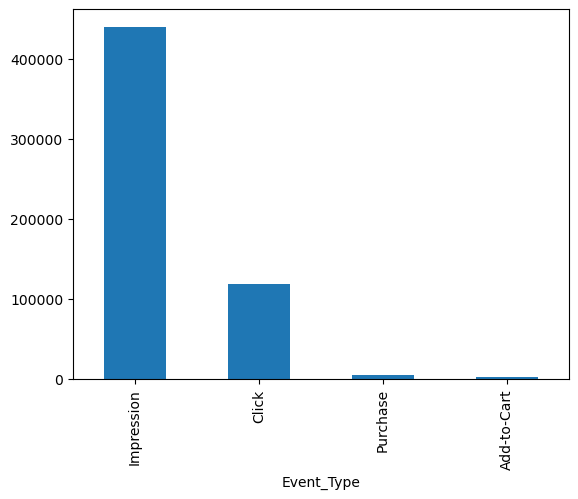

In [44]:
touchpoints['Event_Type'].value_counts().plot(kind='bar')

## 4.2 Channel Performance Analysis

In [45]:
touchpoints['Channel'].value_counts()

Channel
Google Search      115239
Instagram          113529
Marketplace        112947
Influencer Blog    112417
YouTube            112378
Name: count, dtype: int64

<Axes: xlabel='Channel'>

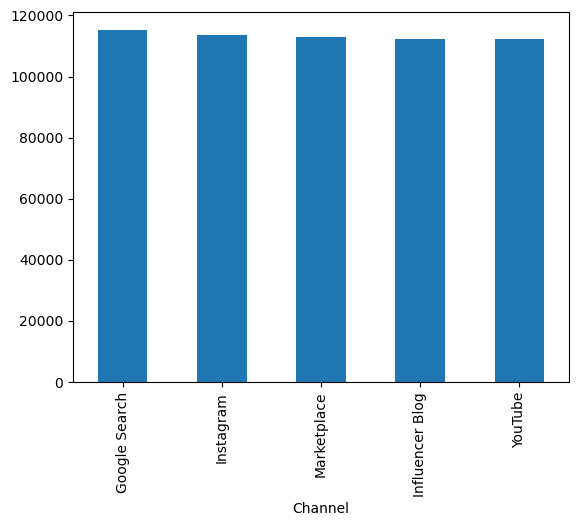

In [46]:
touchpoints['Channel'].value_counts().plot(kind='bar')

In [47]:
pd.crosstab(
    touchpoints['Channel'],
    touchpoints['Event_Type']
)

Event_Type,Add-to-Cart,Click,Impression,Purchase
Channel,,,,
Google Search,619,23718,88241,2661
Influencer Blog,639,23518,87759,501
Instagram,638,23844,88174,873
Marketplace,601,23482,87840,1024
YouTube,630,23629,87680,439


## 4.3 Customer Persona Analysis

In [48]:
user_profiles['Segment'].value_counts()

Segment
Fitness Enthusiast    25115
Budget Parent         25106
Gen-Z Trendseeker     24905
Premium Gourmet       24874
Name: count, dtype: int64

In [49]:
user_profiles['Trend_Affinity'].value_counts()

Trend_Affinity
Sustainable Packaging    20154
Luxury                   20106
Value-Pack               20084
High-Protein             19848
Vegan                    19808
Name: count, dtype: int64

In [50]:
user_profiles['Geography'].value_counts()

Geography
Tier 2    33466
Tier 3    33346
Tier 1    33188
Name: count, dtype: int64

In [51]:
campaign_spend.groupby('Channel')[
    'Total_Budget_Allocated'
].sum()

Channel
Google Search      2.029821e+08
Influencer Blog    1.148977e+08
Instagram          1.941355e+08
Marketplace        2.405746e+08
YouTube            2.660160e+08
Name: Total_Budget_Allocated, dtype: float64

In [52]:
campaign_spend.groupby('Brand_ID')[
    'Total_Budget_Allocated'
].sum()

Brand_ID
B01    1.000000e+08
B02    1.000000e+08
B03    1.000000e+08
B04    1.000000e+08
B05    1.186059e+08
B06    1.000000e+08
B07    1.000000e+08
B08    1.000000e+08
B09    1.000000e+08
B10    1.000000e+08
Name: Total_Budget_Allocated, dtype: float64

# 5. Customer Journey Analysis

Customer journeys were analyzed to understand how users interact with different marketing channels before making a purchase. This phase reconstructs customer paths, identifies common conversion journeys, and measures the average number of touchpoints required before purchase.

In [53]:
purchase_users = touchpoints[
    touchpoints['Event_Type'] == 'Purchase'
]['User_ID'].unique()

In [54]:
len(purchase_users)

5498

In [55]:
purchase_journeys = touchpoints[
    touchpoints['User_ID'].isin(purchase_users)
]

In [56]:
purchase_journeys.shape

(28363, 5)

In [57]:
customer_paths = purchase_journeys.groupby(
    'User_ID'
)['Channel'].apply(list)

In [58]:
customer_paths.head(10)

User_ID
U_B01_00011                       [Google Search, Google Search]
U_B01_00014                  [YouTube, Marketplace, Marketplace]
U_B01_00031    [Google Search, Google Search, Google Search, ...
U_B01_00049    [Google Search, Google Search, Google Search, ...
U_B01_00059    [Instagram, YouTube, Marketplace, YouTube, Goo...
U_B01_00070    [Google Search, Instagram, YouTube, YouTube, I...
U_B01_00144    [Marketplace, YouTube, Marketplace, YouTube, M...
U_B01_00150    [Google Search, Google Search, Instagram, Mark...
U_B01_00159                      [YouTube, Instagram, Instagram]
U_B01_00167    [YouTube, Influencer Blog, Influencer Blog, Ma...
Name: Channel, dtype: object

In [59]:
purchase_journeys.groupby(
    'User_ID'
).size().describe()

count    5498.000000
mean        5.158785
std         1.866003
min         2.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        13.000000
dtype: float64

In [60]:
path_strings = customer_paths.apply(
    lambda x: ' → '.join(x)
)

In [61]:
path_strings.value_counts().head(10)

Channel
Google Search → Google Search                      171
Instagram → Instagram                              107
Marketplace → Marketplace                          102
Influencer Blog → Influencer Blog                   95
YouTube → YouTube                                   78
Influencer Blog → Google Search → Google Search     53
Google Search → Influencer Blog → Google Search     47
Google Search → Google Search → Google Search       45
YouTube → Google Search → Google Search             40
Marketplace → Google Search → Google Search         33
Name: count, dtype: int64

In [62]:
customer_paths_clean = purchase_journeys.groupby(
    'User_ID'
)['Channel'].apply(
    lambda x: list(dict.fromkeys(x))
)

In [63]:
path_strings_clean = customer_paths_clean.apply(
    lambda x: ' → '.join(x)
)

In [64]:
path_strings_clean.value_counts().head(10)

Channel
Google Search                      231
Influencer Blog → Google Search    144
Instagram                          140
Google Search → Influencer Blog    139
Marketplace                        138
Influencer Blog                    133
YouTube                            105
Google Search → Instagram           94
YouTube → Google Search             85
Marketplace → Google Search         82
Name: count, dtype: int64

In [65]:
touchpoints_per_user = purchase_journeys.groupby(
    'User_ID'
).size()

touchpoints_per_user.describe()

count    5498.000000
mean        5.158785
std         1.866003
min         2.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        13.000000
dtype: float64

In [66]:
channel_summary = pd.crosstab(
    touchpoints['Channel'],
    touchpoints['Event_Type']
)

channel_summary['Total_Interactions'] = (
    channel_summary.sum(axis=1)
)

channel_summary['Purchase_Rate'] = (
    channel_summary['Purchase']
    /
    channel_summary['Total_Interactions']
)

channel_summary

Event_Type,Add-to-Cart,Click,Impression,Purchase,Total_Interactions,Purchase_Rate
Channel,,,,,,
Google Search,619,23718,88241,2661,115239,0.023091
Influencer Blog,639,23518,87759,501,112417,0.004457
Instagram,638,23844,88174,873,113529,0.007690
Marketplace,601,23482,87840,1024,112947,0.009066
YouTube,630,23629,87680,439,112378,0.003906


In [67]:
channel_summary.sort_values(
    by='Purchase_Rate',
    ascending=False
)

Event_Type,Add-to-Cart,Click,Impression,Purchase,Total_Interactions,Purchase_Rate
Channel,,,,,,
Google Search,619,23718,88241,2661,115239,0.023091
Marketplace,601,23482,87840,1024,112947,0.009066
Instagram,638,23844,88174,873,113529,0.007690
Influencer Blog,639,23518,87759,501,112417,0.004457
YouTube,630,23629,87680,439,112378,0.003906


In [68]:
channel_budget = campaign_spend.groupby(
    'Channel'
)['Total_Budget_Allocated'].sum()

channel_budget

Channel
Google Search      2.029821e+08
Influencer Blog    1.148977e+08
Instagram          1.941355e+08
Marketplace        2.405746e+08
YouTube            2.660160e+08
Name: Total_Budget_Allocated, dtype: float64

In [69]:
budget_performance = pd.DataFrame({
    'Budget': channel_budget,
    'Purchases': channel_summary['Purchase']
})

budget_performance

,Budget,Purchases
Channel,,
Google Search,2.029821e+08,2661
Influencer Blog,1.148977e+08,501
Instagram,1.941355e+08,873
Marketplace,2.405746e+08,1024
YouTube,2.660160e+08,439


In [70]:
budget_performance['CPA'] = (
    budget_performance['Budget']
    /
    budget_performance['Purchases']
)

budget_performance.sort_values(
    by='CPA'
)

,Budget,Purchases,CPA
Channel,,,
Google Search,2.029821e+08,2661,76280.384213
Instagram,1.941355e+08,873,222377.447858
Influencer Blog,1.148977e+08,501,229336.740279
Marketplace,2.405746e+08,1024,234936.160156
YouTube,2.660160e+08,439,605958.988838


In [71]:
touchpoints_merged = touchpoints.merge(
    user_profiles,
    on='User_ID',
    how='left'
)

In [72]:
pd.crosstab(
    touchpoints_merged['Segment'],
    touchpoints_merged['Channel']
)

Channel,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
Segment,,,,,
Budget Parent,29008,28267,28581,28598,28338
Fitness Enthusiast,29276,28612,28795,28373,28392
Gen-Z Trendseeker,28499,27687,28298,27915,27857
Premium Gourmet,28456,27851,27855,28061,27791


# 6. Last Click Attribution Model

This baseline model replicates the company’s current attribution system where the final channel before purchase receives full conversion credit.

In [73]:
last_touch = purchase_journeys.groupby(
    'User_ID'
).tail(1)

In [74]:
last_click_attribution = last_touch[
    'Channel'
].value_counts()

last_click_attribution

Channel
Google Search      2661
Marketplace        1024
Instagram           873
Influencer Blog     501
YouTube             439
Name: count, dtype: int64

# 7. Multi-Touch Attribution (Markov-Inspired Approach)

A Markov-inspired customer journey framework was implemented to identify channel participation across successful purchase paths and uncover attribution blind spots.

In [75]:
markov_paths = customer_paths_clean.apply(
    lambda x: ['START'] + x + ['CONVERSION']
)

In [76]:
markov_paths.head(10)

User_ID
U_B01_00011                   [START, Google Search, CONVERSION]
U_B01_00014            [START, YouTube, Marketplace, CONVERSION]
U_B01_00031    [START, Google Search, Instagram, YouTube, Mar...
U_B01_00049    [START, Google Search, YouTube, Instagram, CON...
U_B01_00059    [START, Instagram, YouTube, Marketplace, Googl...
U_B01_00070    [START, Google Search, Instagram, YouTube, CON...
U_B01_00144            [START, Marketplace, YouTube, CONVERSION]
U_B01_00150    [START, Google Search, Instagram, Marketplace,...
U_B01_00159              [START, YouTube, Instagram, CONVERSION]
U_B01_00167    [START, YouTube, Influencer Blog, Marketplace,...
Name: Channel, dtype: object

In [77]:
transitions = []

for path in markov_paths:
    for i in range(len(path)-1):
        transitions.append(
            (path[i], path[i+1])
        )

In [78]:
transition_df = pd.DataFrame(
    transitions,
    columns=['From', 'To']
)

transition_df.head()

,From,To
0,START,Google Search
1,Google Search,CONVERSION
2,START,YouTube
3,YouTube,Marketplace
4,Marketplace,CONVERSION


In [79]:
transition_counts = pd.crosstab(
    transition_df['From'],
    transition_df['To']
)

transition_counts

To,CONVERSION,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,,
Google Search,1456,0,723,611,586,556
Influencer Blog,1142,796,0,479,436,423
Instagram,1023,536,501,0,426,394
Marketplace,960,604,465,410,0,384
START,0,1462,1147,988,987,914
YouTube,917,534,440,392,388,0


In [80]:
transition_counts

To,CONVERSION,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,,
Google Search,1456,0,723,611,586,556
Influencer Blog,1142,796,0,479,436,423
Instagram,1023,536,501,0,426,394
Marketplace,960,604,465,410,0,384
START,0,1462,1147,988,987,914
YouTube,917,534,440,392,388,0


In [81]:
transition_probabilities = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

transition_probabilities

To,CONVERSION,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
From,,,,,,
Google Search,0.370295,0.000000,0.183876,0.155392,0.149034,0.141404
Influencer Blog,0.348596,0.242979,0.000000,0.146215,0.133089,0.129121
Instagram,0.355208,0.186111,0.173958,0.000000,0.147917,0.136806
Marketplace,0.340064,0.213957,0.164718,0.145236,0.000000,0.136026
START,0.000000,0.265915,0.208621,0.179702,0.179520,0.166242
YouTube,0.343317,0.199925,0.164732,0.146762,0.145264,0.000000


In [82]:
baseline_conversion = (
    transition_probabilities.loc[
        'START',
        'CONVERSION'
    ]
    if 'CONVERSION' in transition_probabilities.columns
    else 0
)

baseline_conversion

np.float64(0.0)

In [83]:
channels = [
    'Google Search',
    'Instagram',
    'Influencer Blog',
    'Marketplace',
    'YouTube'
]

channel_presence = {}

for channel in channels:
    count = customer_paths_clean.apply(
        lambda x: channel in x
    ).sum()
    
    channel_presence[channel] = count

channel_presence

{'Google Search': np.int64(3932),
 'Instagram': np.int64(2880),
 'Influencer Blog': np.int64(3276),
 'Marketplace': np.int64(2823),
 'YouTube': np.int64(2671)}

In [84]:
markov_contribution = pd.DataFrame(
    channel_presence.items(),
    columns=['Channel', 'Journeys_Involved']
)

markov_contribution['Contribution_%'] = (
    markov_contribution['Journeys_Involved']
    /
    len(customer_paths_clean)
) * 100

markov_contribution.sort_values(
    by='Contribution_%',
    ascending=False
)

,Channel,Journeys_Involved,Contribution_%
0,Google Search,3932,71.516915
2,Influencer Blog,3276,59.585304
1,Instagram,2880,52.382685
3,Marketplace,2823,51.345944
4,YouTube,2671,48.581302


# 8. ROI Optimization & Budget Analysis

In [85]:
final_roi_table = pd.DataFrame({
    'Budget': channel_budget,
    'Purchases': channel_summary['Purchase'],
    'CPA': budget_performance['CPA'],
    'Multi_Touch_Contribution_%':
        markov_contribution.set_index(
            'Channel'
        )['Contribution_%']
})

final_roi_table.sort_values(
    by='Multi_Touch_Contribution_%',
    ascending=False
)

,Budget,Purchases,CPA,Multi_Touch_Contribution_%
Channel,,,,
Google Search,2.029821e+08,2661,76280.384213,71.516915
Influencer Blog,1.148977e+08,501,229336.740279,59.585304
Instagram,1.941355e+08,873,222377.447858,52.382685
Marketplace,2.405746e+08,1024,234936.160156,51.345944
YouTube,2.660160e+08,439,605958.988838,48.581302


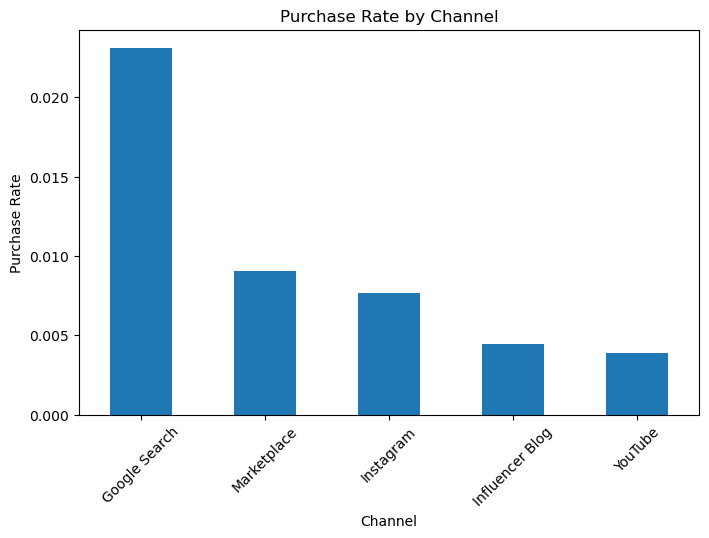

In [91]:
plt.figure(figsize=(8,5))

channel_summary['Purchase_Rate'].sort_values(
    ascending=False
).plot(kind='bar')

plt.title(
    'Purchase Rate by Channel'
)

plt.xlabel('Channel')
plt.ylabel('Purchase Rate')

plt.xticks(rotation=45)

plt.show()

### Insight

Google Search demonstrates the highest purchase rate among all channels, indicating strong lower-funnel conversion capability. Marketplace performs moderately, while Influencer Blog and YouTube show weaker direct conversion rates, suggesting their likely role as awareness or consideration-stage channels.

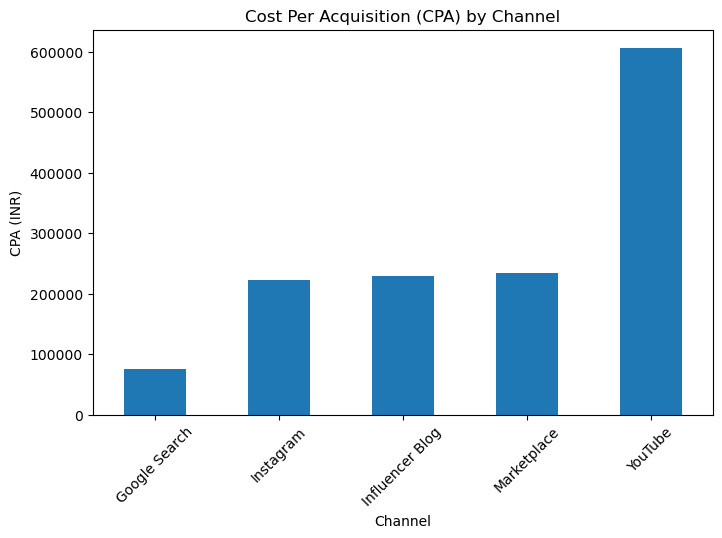

In [92]:
plt.figure(figsize=(8,5))

budget_performance['CPA'].sort_values().plot(
    kind='bar'
)

plt.title(
    'Cost Per Acquisition (CPA) by Channel'
)

plt.xlabel('Channel')
plt.ylabel('CPA (INR)')

plt.xticks(rotation=45)

plt.show()

### Insight

Google Search achieves the lowest customer acquisition cost, making it the most cost-efficient acquisition channel. YouTube exhibits the highest CPA, indicating expensive direct conversions; however, later multi-touch attribution suggests strong assisted conversion influence.

In [93]:
comparison_table = pd.DataFrame({
    'Last_Click': (
        last_click_attribution
        /
        last_click_attribution.sum()
    ) * 100,

    'Multi_Touch': (
        markov_contribution.set_index(
            'Channel'
        )['Contribution_%']
    )
})

comparison_table

,Last_Click,Multi_Touch
Channel,,
Google Search,48.399418,71.516915
Influencer Blog,9.112405,59.585304
Instagram,15.878501,52.382685
Marketplace,18.624955,51.345944
YouTube,7.984722,48.581302


<Figure size 1000x600 with 0 Axes>

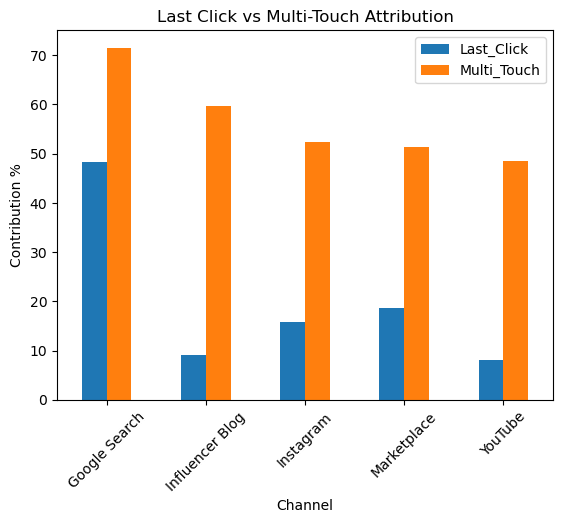

In [94]:
plt.figure(figsize=(10,6))

comparison_table.plot(kind='bar')

plt.title(
    'Last Click vs Multi-Touch Attribution'
)

plt.xlabel('Channel')
plt.ylabel('Contribution %')

plt.xticks(rotation=45)

plt.show()

### Insight

Customer journeys demonstrate strong multi-touch behavior, with users frequently moving between channels before purchase. Patterns such as Influencer Blog → Google Search and YouTube → Google Search suggest that upper-funnel channels play an important role in conversion assistance.

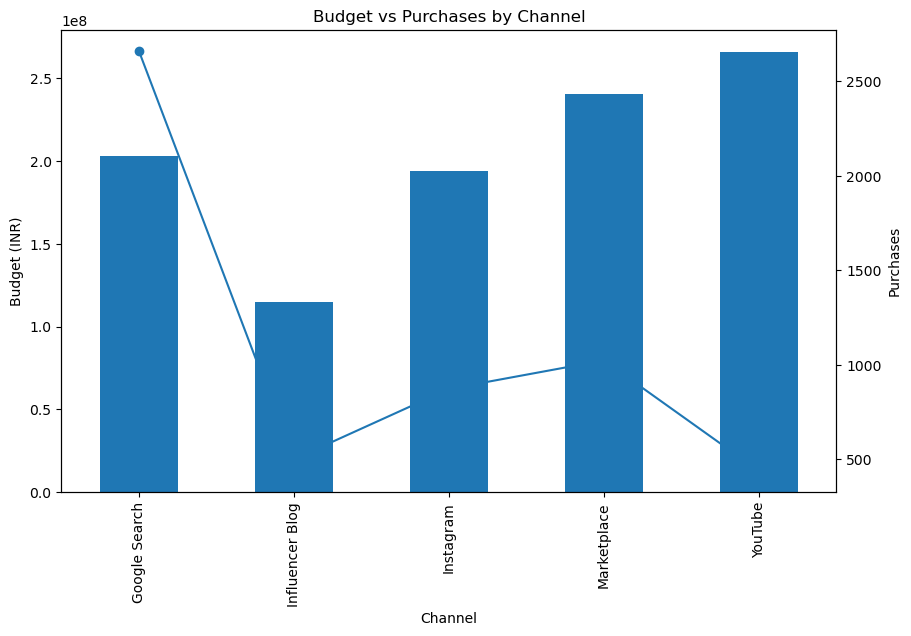

In [96]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Budget bars
final_roi_table['Budget'].plot(
    kind='bar',
    ax=ax1
)

ax1.set_ylabel('Budget (INR)')
ax1.set_title(
    'Budget vs Purchases by Channel'
)

# Second axis for purchases
ax2 = ax1.twinx()

ax2.plot(
    final_roi_table.index,
    final_roi_table['Purchases'],
    marker='o'
)

ax2.set_ylabel('Purchases')

plt.xticks(rotation=45)

plt.show()

# 9. Strategic Recommendations

### Increase Budget
- Google Search

### Protect / Slight Increase
- Influencer Blog

### Maintain
- Instagram

### Reduce & Optimize
- YouTube

### Slight Reduction
- Marketplace

# 10. Conclusion

This project identified major attribution blind spots in traditional last-click attribution models. Through customer journey analysis and multi-touch attribution, upper-funnel channels such as Influencer Blog and YouTube were shown to contribute significantly to successful conversions. The analysis supports a more data-driven budget allocation strategy.